In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

# Memuat dataset
df = pd.read_csv('sensor_kualitas_elektronik.csv')

# Menampilkan dimensi data (baris, kolom)
print("Dimensi Data (Shape):", df.shape)

Dimensi Data (Shape): (1800, 7)


In [3]:
df.head(10)

,ID_Unit,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik,Line_Perakitan,Status_Akhir
0,U00001,11.874,2.160,49.2,16.6,L1,Lolos
1,U00002,11.756,2.396,43.5,17.5,L2,Lolos
2,U00003,12.292,1.790,48.5,18.1,L2,Lolos
3,U00004,11.932,1.894,35.0,20.9,L3,Lolos
4,U00005,NaN,2.202,47.9,13.8,L1,Lolos
5,U00006,12.333,2.208,49.5,14.9,L2,Lolos
6,U00007,12.409,2.274,45.9,14.3,L3,Lolos
7,U00008,NaN,2.254,52.0,20.6,L2,Lolos
8,U00009,11.476,1.617,46.7,17.7,L3,Lolos
9,U00010,11.966,1.880,45.9,15.3,L1,Lolos


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Unit                1800 non-null   str    
 1   Tegangan_Output_Volt   1692 non-null   float64
 2   Arus_Output_Ampere     1674 non-null   float64
 3   Suhu_Komponen_Celcius  1800 non-null   float64
 4   Waktu_Uji_Detik        1800 non-null   float64
 5   Line_Perakitan         1800 non-null   str    
 6   Status_Akhir           1800 non-null   str    
dtypes: float64(4), str(3)
memory usage: 121.4 KB


In [5]:
df.describe()

,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik
count,1692.000000,1674.000000,1800.000000,1800.000000
mean,11.864223,2.055350,45.927667,17.878222
std,0.488638,0.274643,6.688752,3.004420
min,9.750000,1.191000,22.100000,8.600000
25%,11.636000,1.873000,41.300000,15.800000
50%,11.923000,2.036000,45.500000,17.900000
75%,12.193000,2.228000,50.000000,19.900000
max,13.753000,3.049000,76.000000,28.900000


In [7]:
df.isnull().sum()

ID_Unit                    0
Tegangan_Output_Volt     108
Arus_Output_Ampere       126
Suhu_Komponen_Celcius      0
Waktu_Uji_Detik            0
Line_Perakitan             0
Status_Akhir               0
dtype: int64

In [8]:
df_clean = df.copy()

# Imputasi missing value pada Tegangan_Output_Volt menggunakan median
if 'Tegangan_Output_Volt' in df_clean.columns:
    median_tegangan = df_clean['Tegangan_Output_Volt'].median()
    df_clean['Tegangan_Output_Volt'] = df_clean['Tegangan_Output_Volt'].fillna(median_tegangan)

# Imputasi missing value pada Arus_Output_Ampere menggunakan median
if 'Arus_Output_Ampere' in df_clean.columns:
    median_arus = df_clean['Arus_Output_Ampere'].median()
    df_clean['Arus_Output_Ampere'] = df_clean['Arus_Output_Ampere'].fillna(median_arus)

In [9]:
print(df_clean.isnull().sum())

ID_Unit                  0
Tegangan_Output_Volt     0
Arus_Output_Ampere       0
Suhu_Komponen_Celcius    0
Waktu_Uji_Detik          0
Line_Perakitan           0
Status_Akhir             0
dtype: int64


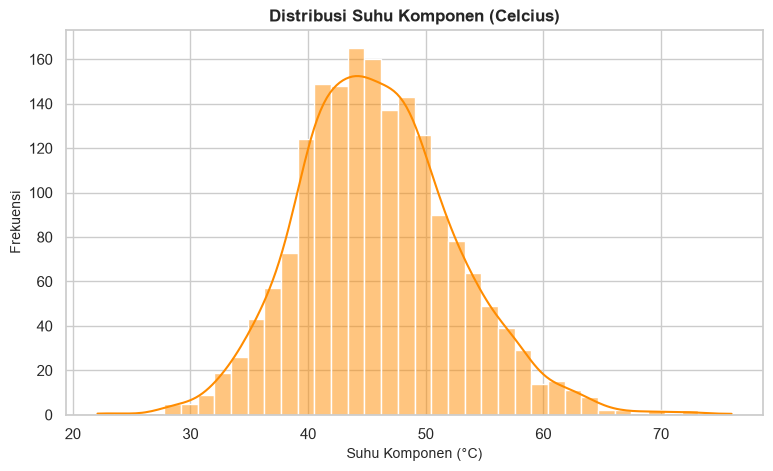

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df_clean['Suhu_Komponen_Celcius'], kde=True, color='darkorange')
plt.title('Distribusi Suhu Komponen (Celcius)', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Komponen (°C)', fontsize=10)
plt.ylabel('Frekuensi', fontsize=10)
plt.show()

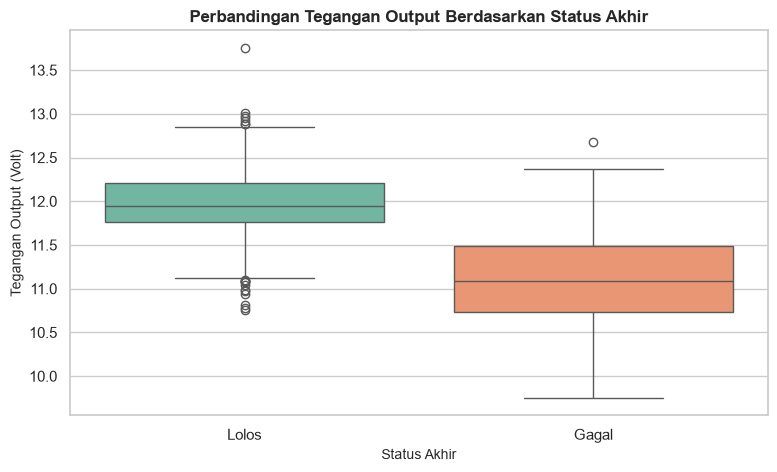

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean, 
    x='Status_Akhir', 
    y='Tegangan_Output_Volt', 
    hue='Status_Akhir', 
    palette='Set2', 
    legend=False
)
plt.title('Perbandingan Tegangan Output Berdasarkan Status Akhir', fontsize=12, fontweight='bold')
plt.xlabel('Status Akhir', fontsize=10)
plt.ylabel('Tegangan Output (Volt)', fontsize=10)
plt.show()

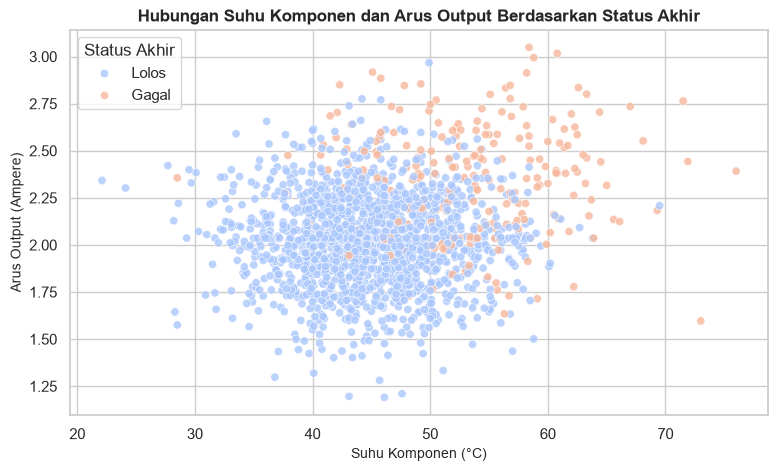

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_clean, 
    x='Suhu_Komponen_Celcius', 
    y='Arus_Output_Ampere', 
    hue='Status_Akhir', 
    palette='coolwarm', 
    alpha=0.8
)
plt.title('Hubungan Suhu Komponen dan Arus Output Berdasarkan Status Akhir', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Komponen (°C)', fontsize=10)
plt.ylabel('Arus Output (Ampere)', fontsize=10)
plt.legend(title='Status Akhir')
plt.show()